
$A_{eff} = A_{min} = 59.1 mm^2 = 5.91e^{-5} m^2$

$\phi_{max} = B_{max} * A_{eff}$

$N_{min} = \frac{L*I_{pk}}{\phi_{max}}$

In [110]:
import math
import numpy as np
# Requirements/Given values
L = 20e-6 # in H, given 20% negative tolerance
I_PK = 6 # in A
B_MAX = 200e-3 # in T
A_RMS = 10 # in A_rms/mm^2
u_0 = 4*math.pi*1e-7 # permeability of free space in H/m
R_SH = 0.05

A_MIN = 5.91e-5 # in m^2
phi_max = B_MAX * A_MIN
N_min = (L*I_PK)/phi_max
print("Minimum number of turns: ", N_min)

Minimum number of turns:  10.152284263959391


In [111]:
awg_to_wire_diameter = { 18: 1.02, 20: 0.81, 22: 0.643, 24: 0.511 }
awg_to_wire_area = { 18: 0.823, 20: 0.518, 22: 0.326, 24: 0.205 }

k = 0.8 # fill factor
N = 11  # number of turns
ind_height = 14.30 # mm
I_rms = math.sqrt(1/3) * I_PK # boundary conduction mode

print(f"Inductor Height: {ind_height} mm\n")

for awg, area in awg_to_wire_area.items():
    wire_diameter = awg_to_wire_diameter[awg]
    max_turns = math.floor(ind_height / wire_diameter)
    
    J_max = I_rms / area
    
    print(f"{awg} AWG:")
    print(f"Max turns physically possible: {max_turns}")
    print(f"Wire area: {area:.3g} mm^2")
    print(f"Current Density (J): {J_max:.2f} A/mm^2\n")

Inductor Height: 14.3 mm

18 AWG:
Max turns physically possible: 14
Wire area: 0.823 mm^2
Current Density (J): 4.21 A/mm^2

20 AWG:
Max turns physically possible: 17
Wire area: 0.518 mm^2
Current Density (J): 6.69 A/mm^2

22 AWG:
Max turns physically possible: 22
Wire area: 0.326 mm^2
Current Density (J): 10.63 A/mm^2

24 AWG:
Max turns physically possible: 27
Wire area: 0.205 mm^2
Current Density (J): 16.90 A/mm^2



$W = \frac{L*I^2}{2}$

In [112]:
W = (L*I_PK**2)/2 # Calculated work of inductor
print(f"Work: {W}")

# maximum current density in the wire in A/mm^2
chosen_awg = 24
J_max = I_rms/(awg_to_wire_area[chosen_awg]) 
print(f"Current Density: {J_max:.5g} A/mm^2")

# nominal values of outer and inner diameter of the winding
D_winding_outer = 18e-3 # m
D_winding_inner = 8.8e-3 # m
A_wind = math.pi * (D_winding_outer**2 - D_winding_inner**2)/4
print(f"Area of winding: {A_wind:.5g}, m^2")

F_max = J_max * k * A_wind

Work: 0.00036
Current Density: 16.898 A/mm^2
Area of winding: 0.00019365, m^2


In [113]:
R_min = (2*W)/(phi_max**2) # minimum reluctance of the air gap
R_max = (F_max**2)/(2*W)

print(f"Minimum reluctance: {R_min:.3e}")
print(f"Maximum reluctance: {R_max:.3e}")
print(f"Range of l_eg: {R_min*(u_0*A_MIN)*10e3:.2g} mm to {R_max*(u_0*A_MIN)*10e3:.2g} mm\n")

Minimum reluctance: 5.153e+06
Maximum reluctance: 9.518e-03
Range of l_eg: 3.8 mm to 7.1e-09 mm



In [114]:
l_eg_in = 0.009*2 # in
l_eg = l_eg_in * 0.0254 #
print(l_eg*1e3)
R_e= l_eg/(u_0 * A_MIN) # reluctance of the air gap
L = 11**2 * (1/R_e)

print(f"Reluctance of the air gap: {R_e:.3e}")
print(f"Inductance with air gap: {L:.3e} H")

0.45719999999999994
Reluctance of the air gap: 6.156e+06
Inductance with air gap: 1.966e-05 H


INSERT SKIN DEPTH CALCULATOR WITH WIRE GAUGE

In [115]:
import pandas as pd
import csv
import matplotlib.pyplot as plt
from scipy.stats import linregress
pd.set_option('display.float_format', lambda x: '%e' % x)

def read_rigol_csv(csv_file_name):
    with open(csv_file_name) as f:
        rows = list(csv.reader(f))

    i = 0
    while rows[0][i] != "":
        i = i + 1

    numcols = i - 2
    t0 = float(rows[1][numcols])
    dT = float(rows[1][numcols+1])

    data = pd.read_csv(csv_file_name, usecols=range(0, numcols), skiprows=[1])
    data['X'] = t0 + data['X'] * dT

    return data, t0, dT

##### Q1, Q2, Q3: 100mV Vsh Peak

Measured Voltage Output: 3.291V

Measured Current Output: 0.18A

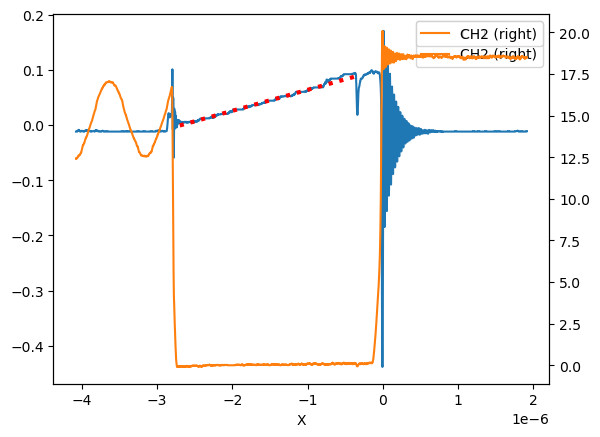

The measured inductance value is 19.31uH


In [116]:
[data, t0, dT] = read_rigol_csv('data/100mV.csv')

Vg = 18

fig, ax = plt.subplots()
data['CH1'] = data['CH1'].rolling(10, min_periods=1).mean()
data['CH2'] = data['CH2'].rolling(10, min_periods=1).mean()
data.plot(x="X", y="CH1", ax = ax)
data.plot(x="X", y="CH2", ax = ax, secondary_y = True)

x1 = -2.7e-6
x2 = -0.3e-6

subset = data[(data['X'] >= x1) & (data['X'] <= x2)]
result = linregress(subset['X'], subset['CH1'])

slope = result.slope

# plot result
fit = slope * subset['X'] + result.intercept
ax.plot(subset['X'], fit, color="red", linewidth=3, linestyle="dotted", label='fit')
plt.legend()
plt.show()

Vout = 3.291 #measured voltage output
Avg_Vd = np.mean(subset['CH2'])

# Vg = Vout + Avg_Vd + Vind
Vind = Vg - Vout - Avg_Vd
di_dt = slope/R_SH
print(f"The measured inductance value is {Vind/di_dt*1e6:.2f}uH")

##### Q4, Q5, Q6: 200mV Vsh Peak

Measured Voltage Output: 7.51V

Measured Current Output: 0.73A

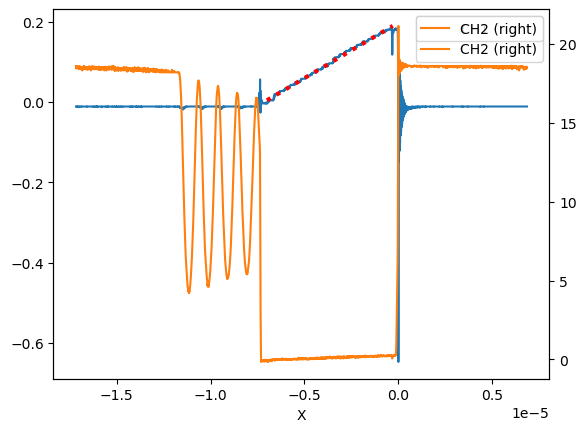

The measured inductance value is 18.80uH


In [117]:
[data, t0, dT] = read_rigol_csv('data/200mV.csv')

fig, ax = plt.subplots()
data['CH1'] = data['CH1'].rolling(10, min_periods=1).mean()
data['CH2'] = data['CH2'].rolling(10, min_periods=1).mean()
data.plot(x="X", y="CH1", ax = ax)
data.plot(x="X", y="CH2", ax = ax, secondary_y = True)

# choose the X range
x1 = -0.7e-5
x2 = -0.03e-5

subset = data[(data['X'] >= x1) & (data['X'] <= x2)]
result = linregress(subset['X'], subset['CH1'])

slope = result.slope

# plot result
fit = slope * subset['X'] + result.intercept

ax.plot(subset['X'], fit, color="red", linewidth=3, linestyle="dotted", label='fit')
plt.legend()
plt.show()

Vout = 7.51 # measured voltage output
Avg_Vd = np.mean(subset['CH2'])

# Vg = Vout + Avg_Vd + Vind
Vind = Vg - Vout - Avg_Vd
di_dt = slope/R_SH
print(f"The measured inductance value is {Vind/di_dt*1e6:.2f}uH")

##### Q7: Document adjustments made and experimental findings.
No adjustments were necessary, since our inductor was found to be between 18.80uH and 19.31 uH, both of which are within the +0%/-20% uH range listed. 

##### Q8: Analyze the potential causes for why the initial design did not meet the desired specifications
The initial design did not meet the maximal RMS current density specification of 10 A_rms/mm^2 because with a 24 AWG, the calculated A_rms/mm^2 is about 16.90 in BCM. An improved design would be with 20 AWG with the same number of turns (11), which has a max current density of 6.69 A_rms/mm^2 in BCM.

In [118]:
awg_to_wire_diameter = { 18: 1.02, 20: 0.81, 22: 0.643, 24: 0.511 }
awg_to_wire_area = { 18: 0.823, 20: 0.518, 22: 0.326, 24: 0.205 }

k = 0.8 # fill factor
N = 11  # number of turns
ind_height = 14.30 # mm
I_rms = math.sqrt(1/3) * I_PK # boundary conduction mode

for awg, area in awg_to_wire_area.items():
    wire_diameter = awg_to_wire_diameter[awg]
    max_turns = math.floor(ind_height / wire_diameter)
    
    J_max = I_rms / area
    print(f"{awg} AWG Current Density (J): {J_max:.2f} A/mm^2\n")

18 AWG Current Density (J): 4.21 A/mm^2

20 AWG Current Density (J): 6.69 A/mm^2

22 AWG Current Density (J): 10.63 A/mm^2

24 AWG Current Density (J): 16.90 A/mm^2



##### Q9: Produce a final drawing for inductor that meets the required specifications.

##### Q10: Update digital twin with actual inductance value, simulate the test operating conditions and compare measured with simulated waveforms.

##### Q11: Use your measurements to plot the Lambda [Vs] versus Current [A] characteristic of your inductor. You will need to integrate the voltage measurement to obtain Lambda.